<a href="https://colab.research.google.com/github/priyanshukr001/Customer-Segmentation/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("/content/Telco_customer_churn (1).xlsx") #copy path from the file

In [ ]:
print(df)

      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


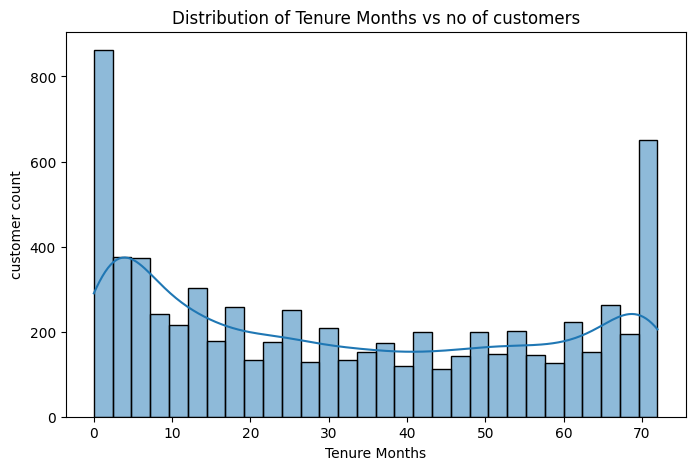

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins = 30, kde = True)
plt.title('Distribution of Tenure Months vs no of customers')
plt.xlabel('Tenure Months')
plt.ylabel('customer count')
plt.show()

In [ ]:
df['Tenure Months'].max()

72

In [ ]:
df['Tenure Months'].min()

0

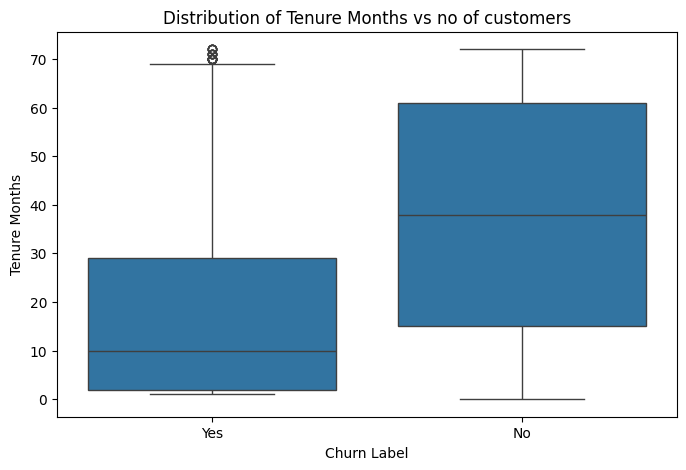

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y = 'Tenure Months', data = df)
plt.title('Distribution of Tenure Months vs no of customers')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df[df['Churn Label'] == 'Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


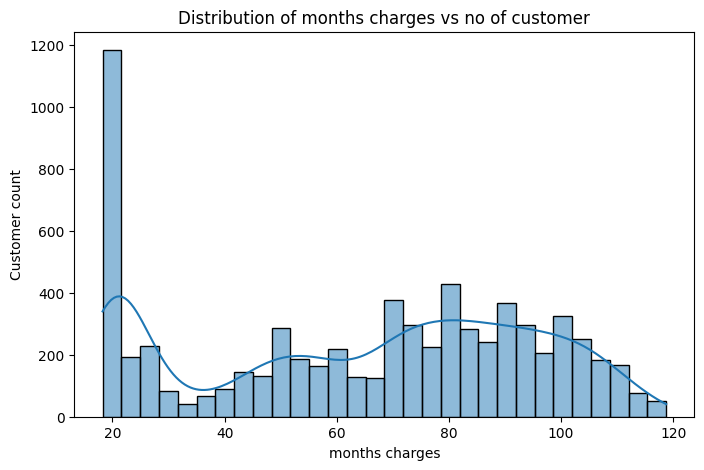

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

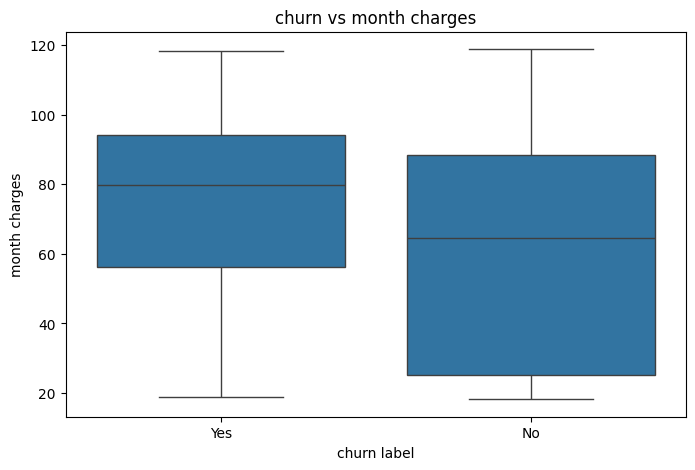

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('month charges')
plt.title('churn vs month charges')
plt.show()

In [ ]:
df[df['Churn Label'] == 'Yes']['Monthly Charges'].quantile(q = [0.25, 0.5, 0.75])
# Means 33 cols mai se voh ros select kr li jha churn lebel YES hai
# ab hum unn rows mai se voh rows select kr lenege aur 25,50,75 percentile values nikal lenge

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Monthly Charges'].quantile(q = [0.25, 0.5, 0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

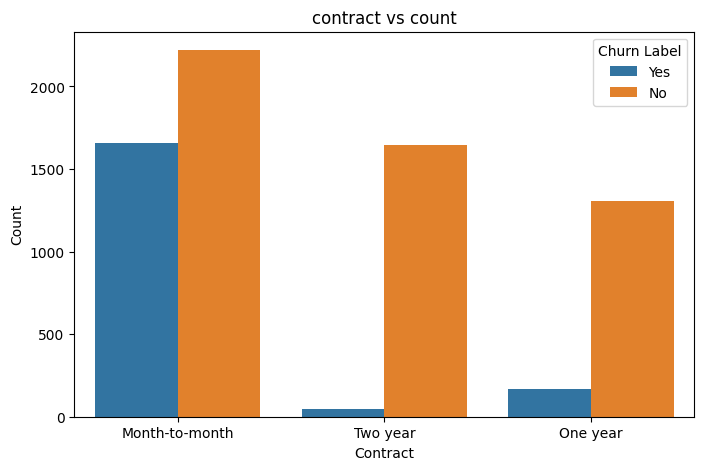

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label', data = df)
plt.title('contract vs count')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Internet Service'].unique() #tells the various services

array(['DSL', 'Fiber optic', 'No'], dtype=object)

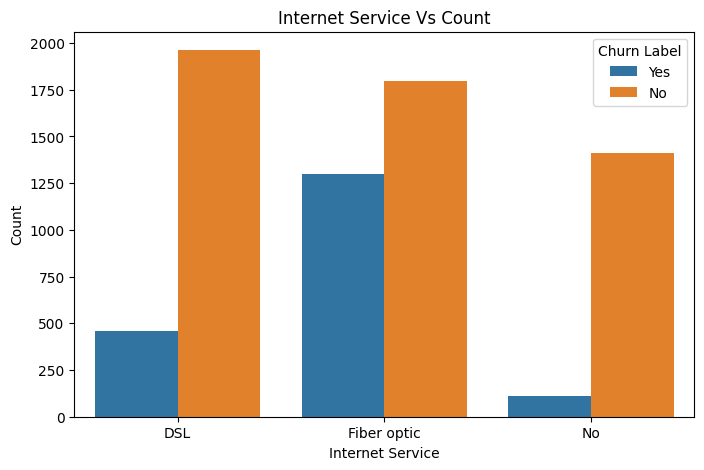

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label', data = df)
plt.title('Internet Service Vs Count')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

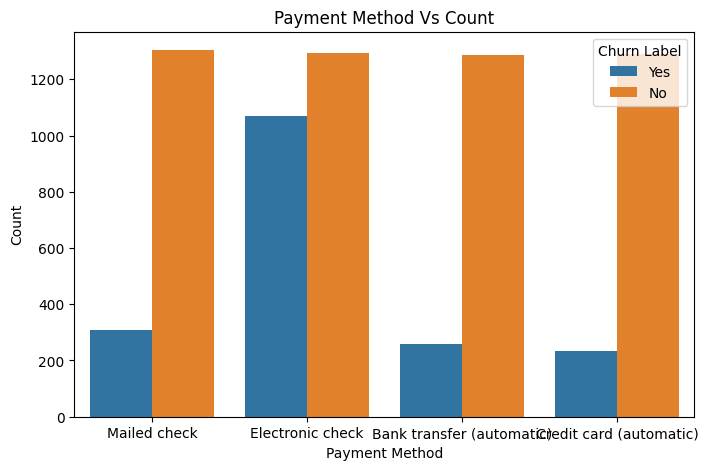

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method',hue='Churn Label', data = df)
plt.title('Payment Method Vs Count')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Tech Support'].unique() #whether the tech support is available or not

array(['No', 'Yes', 'No internet service'], dtype=object)

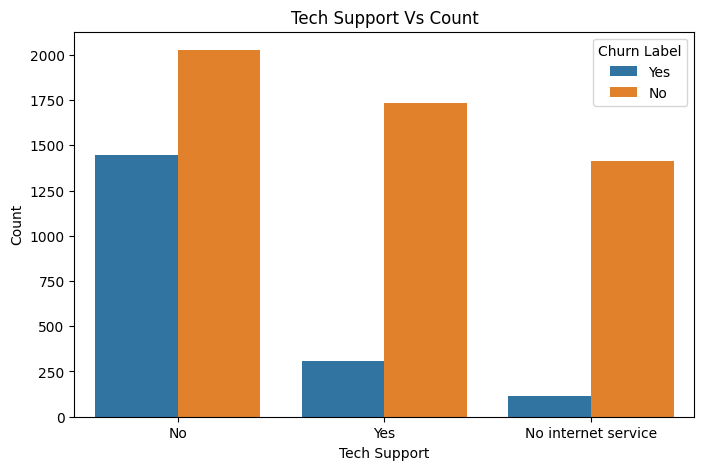

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label', data = df)
plt.title('Tech Support Vs Count')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()

In [ ]:
avg_tenure = df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

NameError: name 'avg_tenure' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
numerical_cols = ['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix = df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
contract_churn = pd.crosstab(df['Contract'],df['Churn Label'],normalize = 'index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data Cleaning

In [ ]:
df.info() # DATA CLEANING

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'],errors = 'coerce')

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


9th June


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df['Total Charges']= df['Total Charges'].fillna(0)
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
drop_columns = ["CustomerID","Count","Country","State","City","Lat Long","Churn Label","Churn Score","CLTV","Churn Reason"]

In [ ]:
df = df.drop(columns=drop_columns)

In [ ]:
df

,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,92285,34.341737,-116.539416,Female,No,No,No,72,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0
7039,92301,34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7040,92304,34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7041,92305,34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.head()

,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,90003,33.964131,-118.272783,2,53.85,108.15,1,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,90005,34.059281,-118.307420,2,70.70,151.65,1,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,90006,34.048013,-118.293953,8,99.65,820.50,1,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,90010,34.062125,-118.315709,28,104.80,3046.05,1,False,False,True,...,False,True,False,True,False,False,True,False,True,False
4,90015,34.039224,-118.266293,49,103.70,5036.30,1,True,False,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 34)

In [ ]:
df.shape

(7043, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.shape

(7043, 16407)

In [ ]:
X=df_encoded.drop('Churn Value',axis=1)
Y=df_encoded["Churn Value"]

In [ ]:
X.shape
Y.shape

(7043,)



# >**Machine Learning Implementation**



In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn Value', axis=1)
Y = df_encoded['Churn Value']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

In [ ]:
X_train.shape

(5634, 16406)

In [ ]:
X_test.shape

(1409, 16406)

In [ ]:
Y_train.shape

(5634,)

In [ ]:
Y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf_model.predict(X_test)

In [ ]:
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [ ]:
Y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(Y_test,y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(Y_test,y_pred)

In [ ]:
print(cm)

[[1009    0]
 [   4  396]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      0.99      0.99       400

    accuracy                           1.00      1409
   macro avg       1.00      0.99      1.00      1409
weighted avg       1.00      1.00      1.00      1409



**Approach 1 --> Handle Class Imbalance**

In [ ]:
rf_model_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [ ]:
rf_model_balanced.fit(X_train,Y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_balanced=rf_model_balanced.predict(X_test)

In [ ]:
accuracy_balanced=accuracy_score(Y_test,y_pred_balanced)

In [ ]:
accuracy_balanced

0.9971611071682044

In [ ]:
cm_balanced=confusion_matrix(Y_test,y_pred_balanced)
print(cm_balanced)
print(classification_report(Y_test,y_pred_balanced))

[[1009    0]
 [   4  396]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      0.99      0.99       400

    accuracy                           1.00      1409
   macro avg       1.00      0.99      1.00      1409
weighted avg       1.00      1.00      1.00      1409



# Approach 2 --> Hyperparameter tuning

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,Y_train)
y_pred_tuned=rf_tuned.predict(X_test)
accuracy_tuned=accuracy_score(Y_test,y_pred_tuned)
cm_tuned=confusion_matrix(Y_test,y_pred_tuned)
print(cm_tuned)
print(classification_report(Y_test,y_pred_tuned))

[[958  51]
 [ 23 377]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1009
           1       0.88      0.94      0.91       400

    accuracy                           0.95      1409
   macro avg       0.93      0.95      0.94      1409
weighted avg       0.95      0.95      0.95      1409



Approach 3 --> Feature Importance Analysis

In [ ]:
import pandas as pd
feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_tuned.feature_importances_
    })

feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                                 Feature  Importance
16386                    Churn Label_Yes    0.109224
6                            Churn Score    0.082374
9836        Internet Service_Fiber optic    0.035362
4                          Tenure Months    0.034860
9840   Online Backup_No internet service    0.033268
...                                  ...         ...
7564                       City_Lakeport    0.000000
7563                       City_Lakehead    0.000000
7562                  City_Lake Isabella    0.000000
7561                    City_Lake Hughes    0.000000
2328               CustomerID_3318-OSATS    0.000000

[16406 rows x 2 columns]


In [ ]:
print(feature_importance.tail(15))

                    Feature  Importance
2329  CustomerID_3319-DWOEP         0.0
7559     City_Lake Elsinore         0.0
2327  CustomerID_3318-NMQXL         0.0
7542          City_La Habra         0.0
7573             City_Laton         0.0
7572           City_Lathrop         0.0
7571          City_Larkspur         0.0
7570           City_Landers         0.0
7566          City_Lakeside         0.0
7565         City_Lakeshore         0.0
7564          City_Lakeport         0.0
7563          City_Lakehead         0.0
7562     City_Lake Isabella         0.0
7561       City_Lake Hughes         0.0
2328  CustomerID_3318-OSATS         0.0


In [ ]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
X_train_sel,X_test_sel,Y_train_sel,Y_test_sel=train_test_split(X_selected,Y,test_size=0.20,random_state=42)


In [ ]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)

print(classification_report(Y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      1009
           1       0.85      0.94      0.89       400

    accuracy                           0.93      1409
   macro avg       0.91      0.94      0.92      1409
weighted avg       0.94      0.93      0.94      1409



Approach Combination of Trees and depth

In [ ]:
from sklearn.metrics import f1_score,accuracy_score, recall_score, precision_score

In [ ]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append({
        'n_estimators':n_trees,
        'max_depth':depth,
        'accuracy':accuracy,
        'recall':recall,
        'precision':precision,
        'f1_score':f1
    })




In [ ]:
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by=['recall','accuracy'],ascending=False)
print(results_df)

    n_estimators  max_depth  accuracy  recall  precision  f1_score
19           500         20  0.961675  0.9600   0.909953  0.934307
11           300         20  0.960965  0.9600   0.907801  0.933171
15           400         20  0.960256  0.9600   0.905660  0.932039
6            200         15  0.957417  0.9600   0.897196  0.927536
7            200         20  0.956707  0.9550   0.898824  0.926061
2            100         15  0.950319  0.9550   0.880184  0.916067
18           500         15  0.953868  0.9500   0.894118  0.921212
10           300         15  0.955997  0.9475   0.902381  0.924390
14           400         15  0.955997  0.9475   0.902381  0.924390
0            100          5  0.904187  0.9475   0.768763  0.848824
5            200         10  0.946061  0.9450   0.875000  0.908654
3            100         20  0.948190  0.9425   0.882904  0.911729
9            300         10  0.947480  0.9425   0.880841  0.910628
13           400         10  0.942512  0.9425   0.866667  0.90

# Cross Model Validation

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')


In [ ]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')


In [ ]:
cv_accuracy

array([0.94960965, 0.93754436, 0.94322214, 0.91477273, 0.94318182])

In [ ]:
cv_accuracy.mean()

np.float64(0.9376661397509517)

In [ ]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')

In [ ]:
cv_recall

array([0.94385027, 0.94652406, 0.94385027, 0.91176471, 0.94906166])

In [ ]:
cv_recall.mean()

np.float64(0.939010193402245)

# Customer Segmentation

In [ ]:
churn_probability = rf_tuned.predict_proba(X)[:,1]

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly Charges':X['Monthly Charges'],
    'Churn Probability':churn_probability
})

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Churn Probability
0,2,53.85,0.594661
1,2,70.70,0.646125
2,8,99.65,0.640244
3,28,104.80,0.607899
4,49,103.70,0.592542
...,...,...,...
7038,72,21.15,0.284690
7039,24,84.80,0.350880
7040,72,103.20,0.425745
7041,11,29.60,0.411355


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [ ]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036  1.22260134]
 [-1.23672422  0.19736523  1.63383674]
 [-0.99240204  1.1595457   1.58683679]
 [-0.17799476  1.33071079  1.32837775]
 [ 0.67713287  1.29415125  1.20567134]]


In [ ]:
from sklearn.cluster import KMeans

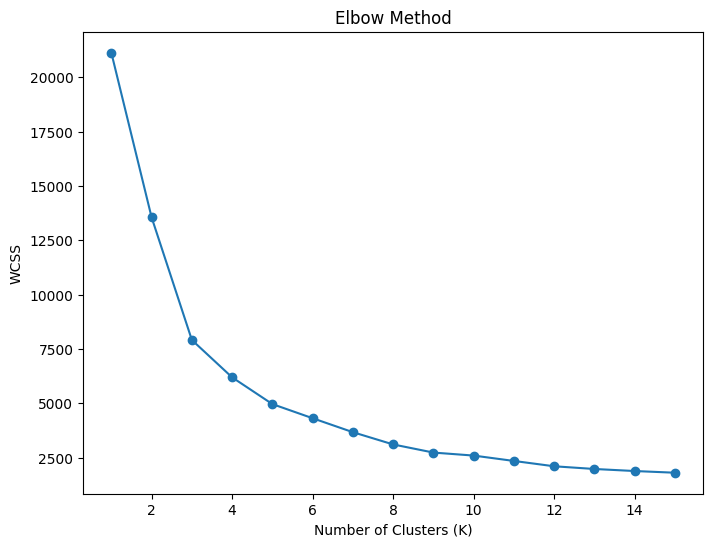

In [ ]:
wcss = []

for k in range(1,16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['Cluster']=clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Churn Probability,Cluster
0,2,53.85,0.594661,2
1,2,70.70,0.646125,2
2,8,99.65,0.640244,2
3,28,104.80,0.607899,2
4,49,103.70,0.592542,1
...,...,...,...,...
7038,72,21.15,0.284690,0
7039,24,84.80,0.350880,1
7040,72,103.20,0.425745,1
7041,11,29.60,0.411355,0


In [ ]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Churn Probability
Cluster,,,
0,29.373308,27.211726,0.320280
1,56.634064,87.488765,0.417206
2,12.643104,73.883750,0.560371


In [ ]:
cluster_summary={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'loyal Premium Customers'
}

In [ ]:
segmentation_data['Customer Segment']=segmentation_data['Cluster'].map(cluster_summary)

Text(0.5, 1.0, 'Customer Segmentation Analysis')

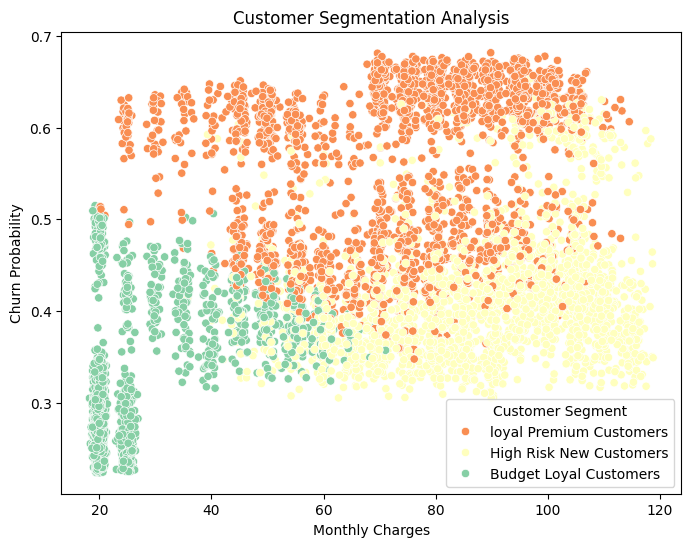

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Customer Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation Analysis')

Text(0.5, 1.0, 'Customer Segmentation Analysis')

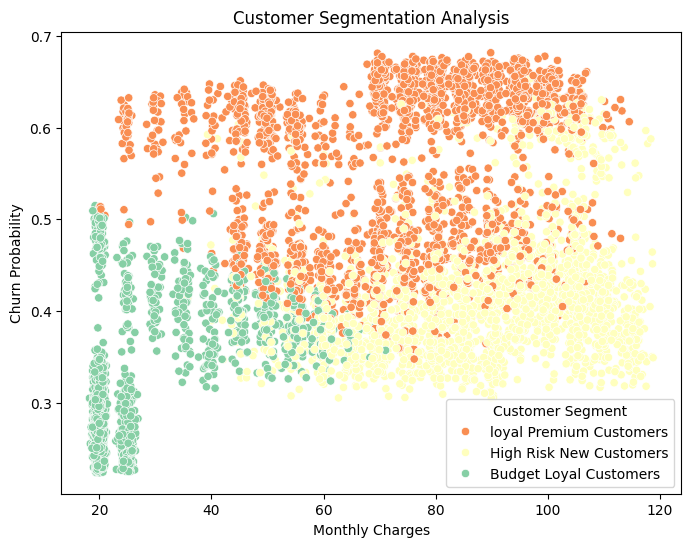

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Customer Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation Analysis')